# stc tv — User Behaviour & Viewer Category Analytics
### تحليل سلوك المشاهدة وفئات المشاهدين في stc tv

**Role:** Senior Data Analyst — stc tv
**Dataset:** `stc TV Data Set_T1.xlsb` (sheet `Final_Dataset`) — one row = one viewing event.

**Analytical framework — the 4 levels of analytics**

| Level | Question it answers | Where it lives in this notebook |
|---|---|---|
| 1. Descriptive  | What happened?      | Sections 3–4 (KPIs, summary stats, Top-10 tables) |
| 2. Diagnostic   | Why did it happen?  | Sections 5–6 (CX drivers, HD/SD, significance tests) |
| 3. Predictive   | What will happen?   | Section 7 (demand forecast + HD-propensity model) |
| 4. Prescriptive | What should we do?  | Section 8 (auto-generated recommendations) |

**UBA objectives:** track engagement · optimise recommendations · surface content insights ·
flag operational/anomalous playback behaviour.

## 0. Environment setup — Google Colab
`pyxlsb` is required to read the binary Excel (`.xlsb`) file. The other libraries ship with Colab.

In [25]:
# --- Colab bootstrap (safe to re-run; silent if already installed) -----------------
try:
    import pyxlsb  # noqa: F401
except ImportError:  # pragma: no cover - Colab first run
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyxlsb"], check=True)

import difflib
import os
import re
import textwrap
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------------
# CONFIGURATION — the few switches that change the behaviour of the whole notebook
# ---------------------------------------------------------------------------------
CONFIG = {
    # Path to the dataset. In Colab: upload the file, or mount Drive and point here.
    "DATA_PATH": "stc TV Data Set_T1.xlsb",
    "SHEET_NAME": "Final_Dataset",
    # A viewing event longer than this is treated as a stuck/abandoned session
    # (device left playing) and excluded from watch-time KPIs — see Section 2.4.
    "MAX_PLAUSIBLE_SESSION_HOURS": 12,
    # A play shorter than this is a "bounce" (browse / mis-click), kept but flagged.
    "BOUNCE_SECONDS": 60,
    # Exact duplicate log rows: report always, drop only if True (see Section 2.3).
    "DROP_EXACT_DUPLICATES": False,
    # Top-N size for all ranking tables.
    "TOP_N": 10,
    # Interactive Plotly rendering (True in Colab; set False for headless batch runs).
    "SHOW_INTERACTIVE": True,
    # Write every result table to ./outputs as CSV + a single Excel workbook.
    "EXPORT_RESULTS": True,
    "OUTPUT_DIR": "outputs",
    "RANDOM_STATE": 42,
}

# --- Presentation defaults --------------------------------------------------------
STC_PURPLE, STC_MAGENTA, STC_TEAL, STC_GREY = "#4F008C", "#E5007D", "#00A19A", "#6E6E73"
PALETTE = [STC_PURPLE, STC_MAGENTA, STC_TEAL, "#FF9E1B", STC_GREY, "#2B6CB0"]
CLASS_COLORS = {"Movie": STC_PURPLE, "Series": STC_MAGENTA}
QUALITY_COLORS = {"HD": STC_TEAL, "SD": STC_GREY}

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 10,
})
pio.templates.default = "plotly_white"

# Plotly renderer: Colab needs its own renderer; elsewhere we emit a lightweight mimetype
# bundle (plotly.js pulled from the CDN) so the saved .ipynb stays small.
try:
    import google.colab  # noqa: F401  (present only inside Colab)
    pio.renderers.default = "colab"
except ImportError:
    pio.renderers.default = os.environ.get("PLOTLY_RENDERER",
                                           "plotly_mimetype+notebook_connected")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

if CONFIG["EXPORT_RESULTS"]:
    os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

RESULT_TABLES = {}  # name -> DataFrame, collected through the notebook and exported at the end


# ---------------------------------------------------------------------------------
# Small presentation helpers
# ---------------------------------------------------------------------------------
def header(title_en: str, title_ar: str = "", char: str = "=") -> None:
    """Print a clearly delimited section header (bilingual)."""
    line = char * 92
    print(f"\n{line}\n{title_en}" + (f"\n{title_ar}" if title_ar else "") + f"\n{line}")


def show_table(df: pd.DataFrame, title: str = "", n: int | None = None, save_as: str | None = None):
    """Print a formatted table, register it for export, and return it unchanged."""
    if title:
        print(f"\n▶ {title}")
    view = df if n is None else df.head(n)
    print(view.to_string())
    if save_as:
        RESULT_TABLES[save_as] = df
    return df


def show_fig(fig) -> None:
    """Render a Plotly figure (interactive in Colab, skipped in headless runs)."""
    if CONFIG["SHOW_INTERACTIVE"]:
        fig.show()


def fmt_int(x) -> str:
    return f"{x:,.0f}"


def fmt_hours(h) -> str:
    return f"{h:,.0f} h ({h / 24:,.0f} days)"

## 1. Data load, working copy & shape
### تحميل البيانات وإنشاء نسخة عمل
Golden rule: **never analyse the original object** — every transformation happens on `df_copy`,
so the raw load (`df`) stays available for reconciliation.

In [26]:
def resolve_data_path(path: str) -> str:
    """Return a usable path to the dataset, offering the Colab upload dialog if it is missing."""
    if os.path.exists(path):
        return path
    try:  # Colab-only fallback
        from google.colab import files  # type: ignore
        print("File not found locally — please upload 'stc TV Data Set_T1.xlsb' ...")
        uploaded = files.upload()
        return list(uploaded.keys())[0]
    except Exception as exc:  # pragma: no cover
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. Upload it, or mount Google Drive and update "
            f"CONFIG['DATA_PATH']."
        ) from exc


def load_raw(path: str, sheet: str) -> pd.DataFrame:
    """Read the .xlsb workbook into a DataFrame (pyxlsb engine, ~1M rows → give it a minute)."""
    print(f"Loading '{path}' [sheet: {sheet}] ...")
    return pd.read_excel(path, sheet_name=sheet, engine="pyxlsb")


df = load_raw(resolve_data_path(CONFIG["DATA_PATH"]), CONFIG["SHEET_NAME"])

# ---- 1.1 ALWAYS work on a copy -----------------------------------------------------
df_copy = df.copy()

header("1. DATASET SHAPE & STRUCTURE", "شكل مجموعة البيانات وهيكلها")
rows, cols = df_copy.shape
print(f"Rows (viewing events / عدد الصفوف)  : {fmt_int(rows)}")
print(f"Columns (الأعمدة)                    : {cols}")
print(f"Memory footprint                     : {df_copy.memory_usage(deep=True).sum()/1e6:,.1f} MB")

schema = pd.DataFrame({
    "dtype": df_copy.dtypes.astype(str),
    "non_null": df_copy.notna().sum(),
    "nulls": df_copy.isna().sum(),
    "null_%": (df_copy.isna().mean() * 100).round(2),
    "unique": df_copy.nunique(),
    "sample_value": [df_copy[c].dropna().iloc[0] if df_copy[c].notna().any() else None
                     for c in df_copy.columns],
})
show_table(schema, "Column inventory / جرد الأعمدة", save_as="01_schema")

print("\n▶ First 5 raw rows:")
print(df_copy.head().to_string())

Loading 'stc TV Data Set_T1.xlsb' [sheet: Final_Dataset] ...

1. DATASET SHAPE & STRUCTURE
شكل مجموعة البيانات وهيكلها
Rows (viewing events / عدد الصفوف)  : 1,048,575
Columns (الأعمدة)                    : 13
Memory footprint                     : 422.0 MB

▶ Column inventory / جرد الأعمدة
                   dtype  non_null  nulls  null_%   unique            sample_value
Column1            int64   1048575      0    0.00  1048575                       1
date_              int64   1048575      0    0.00      411                   42882
user_id_maped      int64   1048575      0    0.00    11578                   26138
program_name      object   1048575      0    0.00     8270              100 treets
duration_seconds   int64   1048575      0    0.00    18958                      40
program_class     object   1048575      0    0.00        2                   MOVIE
season             int64   1048575      0    0.00       22                       0
episode            int64   1048575      0    

## 2. Data cleaning & preprocessing
### تنظيف البيانات والمعالجة المسبقة
Steps: (2.1) missing values → (2.2) types, whitespace & text repair →
(2.3) duplicates → (2.4) implausible durations → (2.5) engineered analysis features.

In [27]:
# ---- 2.1 Missing values -----------------------------------------------------------
header("2.1 MISSING VALUES", "القيم المفقودة")
missing = pd.DataFrame({
    "missing": df_copy.isna().sum(),
    "missing_%": (df_copy.isna().mean() * 100).round(3),
}).query("missing > 0").sort_values("missing", ascending=False)

if missing.empty:
    print("No missing values detected. / لا توجد قيم مفقودة.")
else:
    show_table(missing, "Columns containing nulls", save_as="02_missing_values")
    print(textwrap.dedent("""
    Treatment policy:
      • program_desc  -> descriptive metadata only, so it is NOT imputed. Where it is blank the
                         title simply falls back to program_name (see 2.5), so no row is lost.
      • Key analytical fields (user_id, duration, program_class, hd) must be complete —
        any row missing one of them is dropped, because it cannot be attributed.
    """))

KEY_FIELDS = ["user_id_maped", "duration_seconds", "program_class", "hd", "date_"]
before = len(df_copy)
df_copy = df_copy.dropna(subset=KEY_FIELDS)
print(f"Rows dropped for missing key fields: {fmt_int(before - len(df_copy))}")


# ---- 2.2 Types, whitespace and text repair ----------------------------------------
header("2.2 TYPES, WHITESPACE & TEXT REPAIR", "أنواع البيانات والمسافات الزائدة")

# Excel serial dates (origin 1899-12-30) -> real timestamps
df_copy["date"] = pd.to_datetime(df_copy["date_"], unit="D", origin="1899-12-30")

# Strip whitespace on every text column (the source has trailing spaces, e.g. "The Walking Dead   ")
text_cols = df_copy.select_dtypes(include="object").columns
for c in text_cols:
    df_copy[c] = df_copy[c].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()

# Numeric hygiene
for c in ["user_id_maped", "duration_seconds", "season", "episode", "hd", "series_title"]:
    df_copy[c] = pd.to_numeric(df_copy[c], errors="coerce").astype("Int64")

# Categorical, analysis-friendly labels
df_copy["program_class"] = df_copy["program_class"].str.upper().str.strip()
df_copy["content_type"] = np.where(df_copy["program_class"].str.startswith("MOVIE"), "Movie", "Series")
df_copy["quality"] = np.where(df_copy["hd"] == 1, "HD", "SD")
df_copy["program_genre"] = (df_copy["program_genre"]
                            .replace({"NOT_DEFINED_IN_UMS": "Undefined",
                                      "SERIES_NOT_ADDED_UNDER_ANY_GENRE": "Undefined"})
                            .fillna("Undefined"))

# ---------------------------------------------------------------------------------
# Known encoding artefact in the source export: a capital "S" is dropped from titles.
#   "100 treets"            -> "100 Streets"
#   "SpongeBob quarePants"  -> "SpongeBob SquarePants"
#   "Agents of .H.I.E.L.D." -> "Agents of S.H.I.E.L.D."
# The two content classes need two different repair paths, because they carry the title
# in different places:
#   • MOVIES  — the correct spelling survives inside `program_desc` ("<genre> Movie<title> (HD)").
#   • SERIES  — `program_desc` holds the EPISODE title, not the show name, so the show name
#               in `original_name` has to be repaired directly.
# The direct repair leans on these titles being Title-Cased: a word starting with a lowercase
# letter that is not a stop-word is evidence of a dropped leading capital. It is guarded against
# genuinely lowercase-initial brand names ("iCarly", "iZombie") and against acronyms
# (".H.I.E.L.D."). Accuracy is measured against independent ground truth a few lines below.
# ---------------------------------------------------------------------------------
LOWERCASE_STOPWORDS = {"a", "an", "and", "the", "of", "in", "on", "at", "to", "for", "with",
                       "from", "by", "or", "vs", "de", "la", "le", "el", "al", "und",
                       "is", "it", "my", "me"}


def restore_dropped_s(name):
    """Re-insert the capital 'S' that the source encoding dropped from a Title-Cased name."""
    if not isinstance(name, str) or not name:
        return name
    words = []
    for w in name.split(" "):
        if not w:
            words.append(w)
        elif re.match(r"^\.[A-Z]", w):        # ".H.I.E.L.D."  -> "S.H.I.E.L.D."
            words.append("S" + w)
        elif re.match(r"^[a-z][A-Z]", w):     # "iCarly", "iZombie" -> genuine, leave alone
            words.append(w)
        elif w.lower() in LOWERCASE_STOPWORDS:
            words.append(w)
        elif re.match(r"^[a-z]", w):          # "treets" -> "Streets", "train" -> "Strain"
            words.append("S" + w)
        else:
            words.append(w)
    return " ".join(words)


def clean_title_from_desc(desc, genre=None) -> str | None:
    """Extract the human-readable title embedded in `program_desc`."""
    if not isinstance(desc, str) or not desc.strip():
        return None
    # Layout is "<genre> Movie<title> (HD)"; the genre part may be compound ("Biography%%Drama"),
    # so we cut at the first class keyword rather than trusting the genre column to prefix-match.
    t = re.sub(r"^.*?(?:Movie|Series|Episode)", "", desc, count=1)
    if t == desc and isinstance(genre, str) and t.lower().startswith(genre.lower()):
        t = t[len(genre):]
    t = re.sub(r"\s*\((?:HD|SD)\)\s*$", "", t.strip(), flags=re.I)
    return t.strip() or None


df_copy["title_from_desc"] = [clean_title_from_desc(d, g) for d, g
                              in zip(df_copy["program_desc"], df_copy["program_genre"])]

# --- Score the S-restoration against independent ground truth ----------------------
# Season-level rows (series_title == 1) spell the SHOW name out inside program_desc, which
# gives an independent sample to score the heuristic on. Pairs that are not plausibly the
# same title are dropped first (a few of those rows carry an episode title instead).
_gt = df_copy.loc[df_copy["series_title"].eq(1) & df_copy["program_desc"].notna()].copy()
_gt["_correct"] = (pd.Series([clean_title_from_desc(d, g) for d, g in
                              zip(_gt["program_desc"], _gt["program_genre"])], index=_gt.index)
                   .str.replace(r",\s*(S\d+|Season\s*\d+)\s*$", "", regex=True).str.strip())
_gt["_raw"] = _gt["original_name"].str.replace(r"\s*\(T\)\s*$", "", regex=True).str.strip()
_truth = (_gt.dropna(subset=["_correct"]).groupby("_raw")["_correct"]
          .agg(lambda s: s.mode().iat[0]).to_dict())
_truth = {k: v for k, v in _truth.items() if k and v
          and difflib.SequenceMatcher(None, k.lower(), v.lower()).ratio() >= 0.85}
_hits = sum(restore_dropped_s(k) == v for k, v in _truth.items())
_recovered = (df_copy["title_from_desc"].notna()
              & (df_copy["title_from_desc"] != df_copy["program_name"])).sum()
print(f"Text columns stripped              : {list(text_cols)}")
print(f"Movie titles recovered from desc   : {fmt_int(_recovered)} rows")
print(f"S-restoration accuracy (validated) : {_hits}/{len(_truth)} "
      f"({_hits / max(len(_truth), 1) * 100:.1f}%) vs. independent ground-truth show names")
print(f"Date range / الفترة الزمنية        : {df_copy['date'].min():%Y-%m-%d} → "
      f"{df_copy['date'].max():%Y-%m-%d} "
      f"({(df_copy['date'].max() - df_copy['date'].min()).days + 1} days)")


2.1 MISSING VALUES
القيم المفقودة

▶ Columns containing nulls
              missing  missing_%
program_desc    14038       1.34

Treatment policy:
  • program_desc  -> descriptive metadata only, so it is NOT imputed. Where it is blank the
                     title simply falls back to program_name (see 2.5), so no row is lost.
  • Key analytical fields (user_id, duration, program_class, hd) must be complete —
    any row missing one of them is dropped, because it cannot be attributed.

Rows dropped for missing key fields: 0

2.2 TYPES, WHITESPACE & TEXT REPAIR
أنواع البيانات والمسافات الزائدة
Text columns stripped              : ['program_name', 'program_class', 'program_desc', 'program_genre', 'original_name']
Movie titles recovered from desc   : 646,064 rows
S-restoration accuracy (validated) : 143/144 (99.3%) vs. independent ground-truth show names
Date range / الفترة الزمنية        : 2017-03-14 → 2018-04-30 (413 days)


In [28]:
# ---- 2.3 Duplicate log rows -------------------------------------------------------
header("2.3 DUPLICATE ROWS", "الصفوف المكررة")
dup_cols = [c for c in df_copy.columns if c not in ("Column1", "date")]
dup_mask = df_copy.duplicated(subset=dup_cols, keep="first")
print(f"Exact duplicate rows: {fmt_int(dup_mask.sum())} ({dup_mask.mean()*100:,.2f}% of the log)")
print(textwrap.dedent("""
    Interpretation: the log is stored at day granularity, so a duplicate means
    "same user, same title, same day, same duration". That can legitimately be a repeat play,
    or a double-written log line. We keep them by default (a viewing event is a viewing event)
    and expose CONFIG['DROP_EXACT_DUPLICATES'] so the assumption can be tested in one switch.
"""))
if CONFIG["DROP_EXACT_DUPLICATES"]:
    df_copy = df_copy.loc[~dup_mask].copy()
    print(f"→ Duplicates dropped. Remaining rows: {fmt_int(len(df_copy))}")


# ---- 2.4 Implausible / anomalous session durations (UBA anomaly detection) ---------
header("2.4 SESSION-DURATION ANOMALIES", "شذوذ مدة الجلسات")
df_copy["watch_minutes"] = df_copy["duration_seconds"].astype("float") / 60
df_copy["watch_hours"] = df_copy["duration_seconds"].astype("float") / 3600

max_h = CONFIG["MAX_PLAUSIBLE_SESSION_HOURS"]
df_copy["is_implausible"] = df_copy["watch_hours"] > max_h
df_copy["is_bounce"] = df_copy["duration_seconds"] < CONFIG["BOUNCE_SECONDS"]

anom = df_copy["is_implausible"]
print(f"Sessions longer than {max_h}h (device left playing / possible bot or stuck stream): "
      f"{fmt_int(anom.sum())} rows ({anom.mean()*100:,.3f}%)")
print(f"  ...but they carry {df_copy.loc[anom,'watch_hours'].sum()/df_copy['watch_hours'].sum()*100:,.1f}% "
      f"of all recorded watch time — which is exactly why they must be excluded from KPIs.")
print(f"Bounce plays (< {CONFIG['BOUNCE_SECONDS']}s, browse / mis-click): "
      f"{fmt_int(df_copy['is_bounce'].sum())} rows ({df_copy['is_bounce'].mean()*100:,.1f}%)")

# `valid_time` = the analysis frame for every WATCH-TIME metric.
# Views/users KPIs still use the full log — a 20-hour stuck stream is still a real play event.
valid_time = df_copy.loc[~df_copy["is_implausible"]].copy()
print(f"\nWatch-time analysis frame: {fmt_int(len(valid_time))} rows "
      f"({len(valid_time)/len(df_copy)*100:,.2f}% of events retained)")


2.3 DUPLICATE ROWS
الصفوف المكررة
Exact duplicate rows: 102,074 (9.73% of the log)

Interpretation: the log is stored at day granularity, so a duplicate means
"same user, same title, same day, same duration". That can legitimately be a repeat play,
or a double-written log line. We keep them by default (a viewing event is a viewing event)
and expose CONFIG['DROP_EXACT_DUPLICATES'] so the assumption can be tested in one switch.


2.4 SESSION-DURATION ANOMALIES
شذوذ مدة الجلسات
Sessions longer than 12h (device left playing / possible bot or stuck stream): 2,677 rows (0.255%)
  ...but they carry 18.9% of all recorded watch time — which is exactly why they must be excluded from KPIs.
Bounce plays (< 60s, browse / mis-click): 287,426 rows (27.4%)

Watch-time analysis frame: 1,045,898 rows (99.74% of events retained)


In [29]:
# ---- 2.5 Feature engineering -------------------------------------------------------
header("2.5 ENGINEERED FEATURES", "الحقول المشتقة")


def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add the identity, time and episode-level columns every downstream section relies on."""
    out = frame.copy()

    # Canonical show name. For a series, `original_name` is the SHOW (while `program_name` is
    # "<show>  <episode title>"), so it is the right source — but it carries the dropped-S
    # artefact, which we repair here. The repair is mapped over the ~1.8k DISTINCT names rather
    # than applied row-wise, so it stays cheap on a million-row log.
    base_show = (out["original_name"]
                 .fillna(out["program_name"])
                 .str.replace("\ufffd", "", regex=False)
                 .str.replace(r"\s*\((T|HD|SD)\)\s*$", "", regex=True)
                 .str.strip())
    _show_map = {n: restore_dropped_s(n) for n in base_show.dropna().unique()}
    out["show_name"] = base_show.map(_show_map).fillna(base_show)

    # Movie title: prefer the clean spelling recovered from program_desc, and fall back to a
    # repaired program_name when the description is missing (14k rows have no description).
    _fallback = out["program_name"].str.replace("\ufffd", "", regex=False).str.strip()
    _fb_map = {n: restore_dropped_s(n) for n in _fallback.dropna().unique()}
    out["clean_title"] = out["title_from_desc"].fillna(_fallback.map(_fb_map)).str.strip()

    # --- TV-series episode accounting -----------------------------------------------
    # series_title == 1  -> a season/title-level play (episode metadata absent)
    # episode  > 0       -> a genuine, distinct episode
    is_series = out["content_type"].eq("Series")
    out["play_level"] = np.select(
        [~is_series, is_series & out["episode"].fillna(0).gt(0)],
        ["Movie", "Episode"], default="Season/Title-level")
    out["episode_code"] = np.where(
        out["play_level"].eq("Episode"),
        out["show_name"] + " — S" + out["season"].astype("Int64").astype(str).str.zfill(2)
        + "E" + out["episode"].astype("Int64").astype(str).str.zfill(2),
        pd.NA)
    out["episode_label"] = np.where(
        out["play_level"].eq("Episode"),
        out["episode_code"] + " · " + out["clean_title"].fillna(""), pd.NA)
    # One asset-level key that works for both classes (movie title | series episode).
    out["asset_key"] = np.where(is_series, out["episode_code"].fillna(out["show_name"]),
                                out["clean_title"].fillna(out["program_name"]))

    # --- Calendar features ------------------------------------------------------------
    out["year_month"] = out["date"].dt.to_period("M").dt.to_timestamp()
    out["weekday"] = out["date"].dt.day_name()
    out["is_weekend"] = out["date"].dt.dayofweek.isin([4, 5])  # Fri/Sat weekend (KSA, 2017-18)
    return out


df_copy = build_features(df_copy)
valid_time = build_features(valid_time)

print(df_copy["play_level"].value_counts().to_frame("rows").to_string())
print(f"\nDistinct movies              : {fmt_int(df_copy.loc[df_copy.content_type=='Movie','asset_key'].nunique())}")
print(f"Distinct series (shows)      : {fmt_int(df_copy.loc[df_copy.content_type=='Series','show_name'].nunique())}")
print(f"Distinct series EPISODES     : {fmt_int(df_copy['episode_code'].nunique())}")
print(f"Distinct users               : {fmt_int(df_copy['user_id_maped'].nunique())}")
print("\n▶ Cleaned sample:")
print(df_copy[["date", "user_id_maped", "content_type", "show_name", "asset_key",
               "program_genre", "quality", "watch_minutes", "play_level"]].head(8).to_string())


2.5 ENGINEERED FEATURES
الحقول المشتقة
                      rows
play_level                
Episode             547480
Movie               488401
Season/Title-level   12694

Distinct movies              : 1,557
Distinct series (shows)      : 253
Distinct series EPISODES     : 9,616
Distinct users               : 11,578

▶ Cleaned sample:
        date  user_id_maped content_type                        show_name                        asset_key program_genre quality  watch_minutes play_level
0 2017-05-27          26138        Movie                      100 Streets                      100 Streets         Drama      SD           0.67      Movie
1 2017-05-21           7946        Movie                            Moana                            Moana     Animation      HD           0.28      Movie
2 2017-08-10           7418        Movie             The Mermaid Princess             The Mermaid Princess     Animation      HD           0.13      Movie
3 2017-07-26          19307        Mov

## 3. Descriptive analytics — baseline KPIs & summary statistics
### التحليل الوصفي: المؤشرات الأساسية والإحصاءات الوصفية
Mean (المتوسط الحسابي) · Standard deviation (الانحراف المعياري) · Min & Max (القيم الصغرى والعظمى).

In [30]:
def numeric_summary(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Mean / Std / Min / Max (+ median & quartiles for context) for the requested columns."""
    num = frame[columns].astype("float")
    summary = pd.DataFrame({
        "count / العدد": num.count(),
        "mean / المتوسط الحسابي": num.mean(),
        "std / الانحراف المعياري": num.std(),
        "min / القيمة الصغرى": num.min(),
        "25%": num.quantile(0.25),
        "median / الوسيط": num.median(),
        "75%": num.quantile(0.75),
        "max / القيمة العظمى": num.max(),
    })
    return summary.round(2)


header("3.1 SUMMARY STATISTICS — ALL NUMERIC COLUMNS", "الإحصاءات الوصفية لكل الأعمدة الرقمية")
NUMERIC_COLS = ["duration_seconds", "watch_minutes", "watch_hours", "season", "episode", "hd"]
show_table(numeric_summary(df_copy, NUMERIC_COLS),
           "Raw log (all events) / السجل الكامل", save_as="03_summary_raw")
show_table(numeric_summary(valid_time, NUMERIC_COLS),
           f"After removing sessions > {CONFIG['MAX_PLAUSIBLE_SESSION_HOURS']}h "
           f"(the frame used for watch-time KPIs)", save_as="03_summary_clean")

print(textwrap.dedent(f"""
    Reading the numbers:
      • The raw mean session ({df_copy.watch_minutes.mean():,.1f} min) sits far above the median
        ({df_copy.watch_minutes.median():,.1f} min) and the std ({df_copy.watch_minutes.std():,.1f})
        is many times the mean → a heavily right-skewed distribution driven by stuck sessions.
      • On the cleaned frame the mean drops to {valid_time.watch_minutes.mean():,.1f} min —
        this is the number to quote to the business.
      • Median >> mean gap means AVERAGES ALONE MISLEAD here: always pair mean with median.
"""))


3.1 SUMMARY STATISTICS — ALL NUMERIC COLUMNS
الإحصاءات الوصفية لكل الأعمدة الرقمية

▶ Raw log (all events) / السجل الكامل
                  count / العدد  mean / المتوسط الحسابي  std / الانحراف المعياري  min / القيمة الصغرى   25%  median / الوسيط      75%  max / القيمة العظمى
duration_seconds        1048575                1,230.96                 6,821.06                 2.00 52.00           119.00 1,328.00         1,461,329.00
watch_minutes           1048575                   20.52                   113.68                 0.03  0.87             1.98    22.13            24,355.48
watch_hours             1048575                    0.34                     1.89                 0.00  0.01             0.03     0.37               405.92
season                  1048575                    1.34                     2.10                 0.00  0.00             1.00     1.00                23.00
episode                 1048575                    6.16                    12.22                 0.00 

In [31]:
# ---- 3.2 Headline KPI board --------------------------------------------------------
header("3.2 HEADLINE KPIs", "لوحة المؤشرات الرئيسية")
total_views = len(df_copy)
total_users = df_copy["user_id_maped"].nunique()
total_hours = valid_time["watch_hours"].sum()
period_days = (df_copy["date"].max() - df_copy["date"].min()).days + 1

KPIS = {
    "Total views / إجمالي المشاهدات": fmt_int(total_views),
    "Unique users / عدد المستخدمين": fmt_int(total_users),
    "Total watch time / وقت المشاهدة الإجمالي": fmt_hours(total_hours),
    "Distinct assets (movies + episodes)": fmt_int(df_copy["asset_key"].nunique()),
    "Views per user": f"{total_views / total_users:,.1f}",
    "Watch hours per user": f"{total_hours / total_users:,.1f}",
    "Avg session (mean / median)": f"{valid_time.watch_minutes.mean():,.1f} / "
                                   f"{valid_time.watch_minutes.median():,.1f} min",
    "HD share of views": f"{df_copy['hd'].mean()*100:,.1f}%",
    "Series share of views": f"{(df_copy.content_type=='Series').mean()*100:,.1f}%",
    "Bounce rate (<60s)": f"{df_copy['is_bounce'].mean()*100:,.1f}%",
    "Reporting period": f"{df_copy['date'].min():%Y-%m-%d} → {df_copy['date'].max():%Y-%m-%d} "
                        f"({period_days} days)",
}
kpi_df = pd.DataFrame(KPIS.items(), columns=["KPI", "Value"])
show_table(kpi_df, "stc tv — platform scorecard", save_as="04_kpi_scorecard")


3.2 HEADLINE KPIs
لوحة المؤشرات الرئيسية

▶ stc tv — platform scorecard
                                         KPI                               Value
0             Total views / إجمالي المشاهدات                           1,048,575
1              Unique users / عدد المستخدمين                              11,578
2   Total watch time / وقت المشاهدة الإجمالي             290,861 h (12,119 days)
3        Distinct assets (movies + episodes)                              11,324
4                             Views per user                                90.6
5                       Watch hours per user                                25.1
6                Avg session (mean / median)                      16.7 / 1.9 min
7                          HD share of views                               38.6%
8                      Series share of views                               53.4%
9                         Bounce rate (<60s)                               27.4%
10                          Reportin

,KPI,Value
0,Total views / إجمالي المشاهدات,"1,048,575"
1,Unique users / عدد المستخدمين,"11,578"
2,Total watch time / وقت المشاهدة الإجمالي,"290,861 h (12,119 days)"
3,Distinct assets (movies + episodes),"11,324"
4,Views per user,90.6
5,Watch hours per user,25.1
6,Avg session (mean / median),16.7 / 1.9 min
7,HD share of views,38.6%
8,Series share of views,53.4%
9,Bounce rate (<60s),27.4%


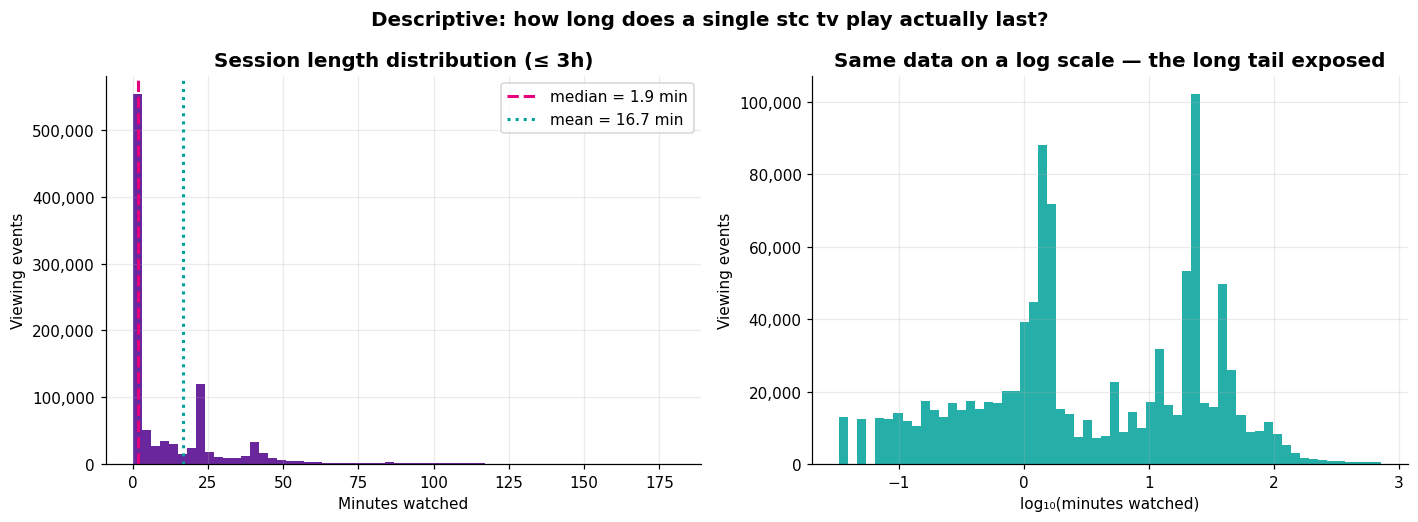

In [32]:
# ---- 3.3 Distribution of viewing time ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(valid_time.loc[valid_time.watch_minutes <= 180, "watch_minutes"],
             bins=60, color=STC_PURPLE, alpha=0.85)
axes[0].axvline(valid_time.watch_minutes.median(), color=STC_MAGENTA, ls="--", lw=2,
                label=f"median = {valid_time.watch_minutes.median():,.1f} min")
axes[0].axvline(valid_time.watch_minutes.mean(), color=STC_TEAL, ls=":", lw=2,
                label=f"mean = {valid_time.watch_minutes.mean():,.1f} min")
axes[0].set(title="Session length distribution (≤ 3h)", xlabel="Minutes watched", ylabel="Viewing events")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

log_minutes = np.log10(valid_time["watch_minutes"].clip(lower=1 / 60))
axes[1].hist(log_minutes, bins=60, color=STC_TEAL, alpha=0.85)
axes[1].set(title="Same data on a log scale — the long tail exposed",
            xlabel="log₁₀(minutes watched)", ylabel="Viewing events")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.suptitle("Descriptive: how long does a single stc tv play actually last?",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Program class analysis — Movies vs. TV Series
### تحليل فئات البرامج: الأفلام مقابل المسلسلات
Views (إجمالي المشاهدات) · Unique users (عدد المستخدمين) · Watch time (وقت المشاهدة الإجمالي).
For series we deliberately separate **show level**, **season level** and **distinct episode level**,
because 1 series view ≠ 1 movie view: a series accumulates views across many episodes.

In [33]:
def class_profile(events: pd.DataFrame, timed: pd.DataFrame) -> pd.DataFrame:
    """Build the Movie vs. Series comparison table (views/users from events, hours from `timed`)."""
    agg = events.groupby("content_type").agg(
        total_views=("user_id_maped", "size"),
        unique_users=("user_id_maped", "nunique"),
        distinct_assets=("asset_key", "nunique"),
        bounce_rate=("is_bounce", "mean"),
        hd_share=("hd", "mean"),
    )
    hours = timed.groupby("content_type").agg(
        total_watch_hours=("watch_hours", "sum"),
        avg_minutes_per_view=("watch_minutes", "mean"),
        median_minutes_per_view=("watch_minutes", "median"),
    )
    out = agg.join(hours)
    out["views_per_user"] = out.total_views / out.unique_users
    out["watch_hours_per_user"] = out.total_watch_hours / out.unique_users
    out["share_of_views_%"] = out.total_views / out.total_views.sum() * 100
    out["share_of_watch_time_%"] = out.total_watch_hours / out.total_watch_hours.sum() * 100
    out["bounce_rate"] = out.bounce_rate * 100
    out["hd_share"] = out.hd_share * 100
    return out.rename(columns={"bounce_rate": "bounce_rate_%", "hd_share": "hd_share_%"}).round(2)


header("4.1 MOVIES vs. SERIES — HEAD-TO-HEAD", "الأفلام مقابل المسلسلات")
class_tbl = class_profile(df_copy, valid_time)
show_table(class_tbl.T, "Program-class scorecard", save_as="05_class_scorecard")

# ---- 4.2 Series-specific episode accounting ---------------------------------------
header("4.2 SERIES DEPTH — EPISODE & SEASON ACCOUNTING", "تفصيل المسلسلات: المواسم والحلقات")
series = df_copy[df_copy.content_type == "Series"]
series_depth = pd.Series({
    "Distinct shows / عدد المسلسلات": series["show_name"].nunique(),
    "Distinct seasons": series.loc[series.season > 0].groupby("show_name")["season"].nunique().sum(),
    "Distinct episodes / عدد الحلقات": series["episode_code"].nunique(),
    "Episode-level plays": (series.play_level == "Episode").sum(),
    "Season/title-level plays": (series.play_level == "Season/Title-level").sum(),
    "Avg episodes available per show": series.groupby("show_name")["episode_code"].nunique().mean(),
    "Avg distinct episodes watched per user": series.groupby("user_id_maped")["episode_code"]
                                                    .nunique().mean(),
    "Max distinct episodes by one user (binge depth)": series.groupby("user_id_maped")["episode_code"]
                                                             .nunique().max(),
}).round(2)
show_table(series_depth.to_frame("value"), "Series structural metrics", save_as="06_series_depth")

# ---- 4.3 TOP 10 tables -------------------------------------------------------------
def top_n(events, timed, key, label, n=CONFIG["TOP_N"], extra=None):
    """Rank content by views, enriched with users + watch time (dropping stuck sessions)."""
    base = events.groupby(key).agg(
        total_views=("user_id_maped", "size"),
        unique_users=("user_id_maped", "nunique"),
        hd_share_pct=("hd", lambda s: s.mean() * 100),
    )
    tm = timed.groupby(key).agg(
        total_watch_hours=("watch_hours", "sum"),
        avg_minutes=("watch_minutes", "mean"),
    )
    out = base.join(tm)
    if extra is not None:
        out = out.join(extra)
    out["views_per_user"] = out.total_views / out.unique_users
    out = out.sort_values("total_views", ascending=False).head(n).round(2)
    out.index.name = label
    return out


header(f"4.3 TOP {CONFIG['TOP_N']} CONTENT TABLES", "أفضل ١٠ محتويات")
movies_e = df_copy[df_copy.content_type == "Movie"]
movies_t = valid_time[valid_time.content_type == "Movie"]
series_t = valid_time[valid_time.content_type == "Series"]

top_movies = top_n(movies_e, movies_t, "asset_key", "Movie")
show_table(top_movies, "TOP 10 MOVIES by total views / أكثر ١٠ أفلام مشاهدة", save_as="07_top_movies_views")

top_movies_time = (top_n(movies_e, movies_t, "asset_key", "Movie", n=len(movies_e["asset_key"].unique()))
                   .sort_values("total_watch_hours", ascending=False).head(CONFIG["TOP_N"]))
show_table(top_movies_time, "TOP 10 MOVIES by total watch time", save_as="08_top_movies_time")

genre_of_show = series.groupby("show_name")["program_genre"].agg(lambda s: s.mode().iat[0])
top_shows = top_n(series, series_t, "show_name", "TV Series",
                  extra=pd.concat([genre_of_show.rename("genre"),
                                   series.groupby("show_name")["episode_code"].nunique()
                                         .rename("distinct_episodes")], axis=1))
show_table(top_shows, "TOP 10 TV SERIES (show level) by total views / أكثر ١٠ مسلسلات مشاهدة",
           save_as="09_top_series_views")

episodes_e = series[series.play_level == "Episode"]
episodes_t = series_t[series_t.play_level == "Episode"]
top_episodes = top_n(episodes_e, episodes_t, "episode_code", "Episode")
show_table(top_episodes, "TOP 10 INDIVIDUAL EPISODES by total views / أكثر ١٠ حلقات مشاهدة",
           save_as="10_top_episodes_views")

top_episodes_time = (top_n(episodes_e, episodes_t, "episode_code", "Episode",
                           n=episodes_e["episode_code"].nunique())
                     .sort_values("total_watch_hours", ascending=False).head(CONFIG["TOP_N"]))
show_table(top_episodes_time, "TOP 10 EPISODES by total watch time", save_as="11_top_episodes_time")


4.1 MOVIES vs. SERIES — HEAD-TO-HEAD
الأفلام مقابل المسلسلات

▶ Program-class scorecard
content_type                Movie     Series
total_views                488401     560174
unique_users                11355       3901
distinct_assets              1557       9771
bounce_rate_%               38.13      18.07
hd_share_%                  67.92      13.08
total_watch_hours       84,771.77 206,089.34
avg_minutes_per_view        10.43      22.15
median_minutes_per_view      1.28      18.63
views_per_user              43.01     143.60
watch_hours_per_user         7.47      52.83
share_of_views_%            46.58      53.42
share_of_watch_time_%       29.15      70.85

4.2 SERIES DEPTH — EPISODE & SEASON ACCOUNTING
تفصيل المسلسلات: المواسم والحلقات

▶ Series structural metrics
                                                     value
Distinct shows / عدد المسلسلات                      253.00
Distinct seasons                                    503.00
Distinct episodes / عدد الحلقات       

,total_views,unique_users,hd_share_pct,total_watch_hours,avg_minutes,views_per_user
Episode,,,,,,
PAW Patrol — S01E01,1774,407,0,473.25,16.02,4.36
PAW Patrol — S01E02,1439,334,0,450.77,18.82,4.31
PAW Patrol — S01E03,1296,294,0,429.28,19.89,4.41
PAW Patrol — S01E04,1334,283,0,422.14,19.00,4.71
PAW Patrol — S01E05,1222,268,0,419.33,20.62,4.56
PAW Patrol — S01E06,1198,256,0,404.59,20.28,4.68
Blaze And The Monster Machines — S01E01,1508,369,0,388.21,15.45,4.09
Blaze And The Monster Machines — S01E02,1291,258,0,387.43,18.02,5.00
Shimmer And Shine — S01E01,1479,427,0,367.38,14.93,3.46


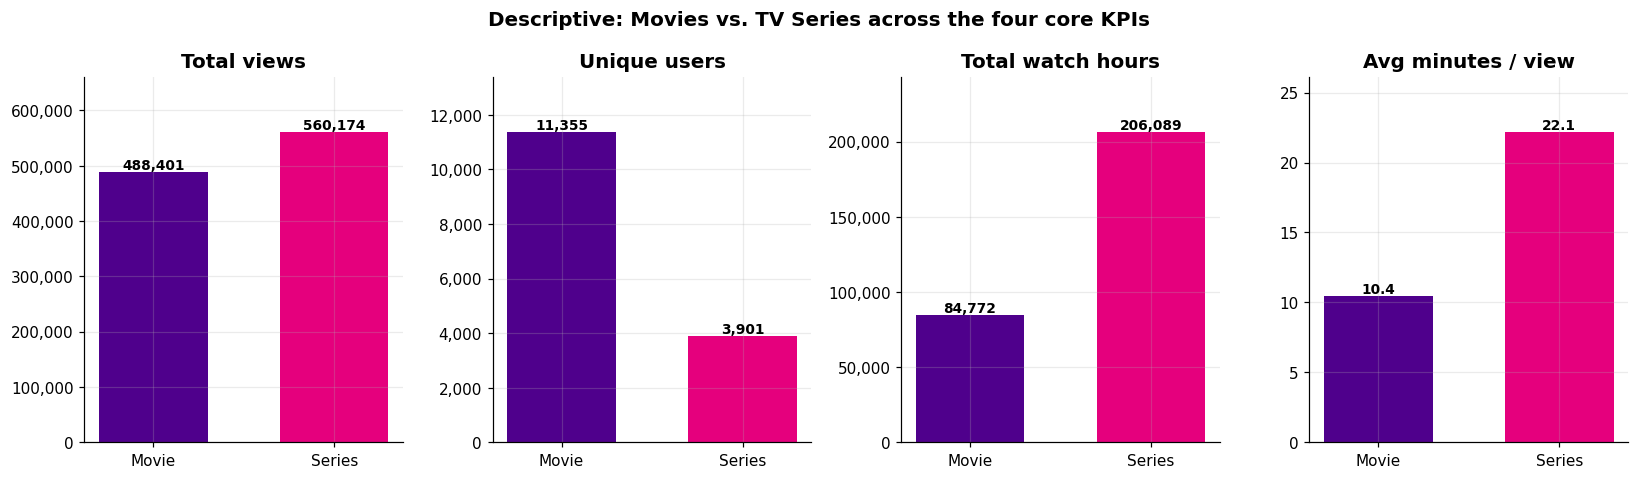

In [34]:
# ---- 4.4 Visualising the class comparison ------------------------------------------
metrics = [("total_views", "Total views", fmt_int),
           ("unique_users", "Unique users", fmt_int),
           ("total_watch_hours", "Total watch hours", fmt_int),
           ("avg_minutes_per_view", "Avg minutes / view", lambda v: f"{v:,.1f}")]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.4))
for ax, (col, title, formatter) in zip(axes, metrics):
    vals = class_tbl[col]
    bars = ax.bar(vals.index, vals.values, color=[CLASS_COLORS[i] for i in vals.index], width=0.6)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, v, formatter(v), ha="center", va="bottom",
                fontweight="bold", fontsize=9)
    ax.margins(y=0.18)
fig.suptitle("Descriptive: Movies vs. TV Series across the four core KPIs",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Interactive Top-10 bars (Plotly)
top_plot = (pd.concat([top_movies.assign(content_type="Movie").reset_index()
                       .rename(columns={"Movie": "title"}),
                       top_shows.assign(content_type="Series").reset_index()
                       .rename(columns={"TV Series": "title"})], ignore_index=True)
            .sort_values("total_views"))
fig = px.bar(top_plot, x="total_views", y="title", color="content_type", orientation="h",
             color_discrete_map=CLASS_COLORS,
             hover_data=["unique_users", "total_watch_hours", "avg_minutes", "hd_share_pct"],
             title="Top 10 Movies & Top 10 TV Series by total views — stc tv",
             labels={"total_views": "Total views", "title": "", "content_type": "Class"})
fig.update_layout(height=760, bargap=0.25, legend_title_text="")
show_fig(fig)

## 5. Customer experience & viewing behaviour
### تجربة العميل وسلوك المشاهدة
The core CX question: **does watch time scale with audience size, and does it scale differently
for movies and series?** Reach (unique users) and depth (watch hours) are two different
business levers — content that wins on one can lose badly on the other.


5.1 REACH vs. DEPTH BY TITLE
الوصول مقابل العمق لكل عنوان
Correlation between unique users and total watch hours (all titles): r = 0.775

▶ Correlation by program class
              corr(users, watch_hours)
content_type                          
Movie                             0.77
Series                            0.86

▶ Engagement intensity per title / كثافة التفاعل لكل عنوان
             hours_per_user        views_per_user        avg_minutes       
                       mean median           mean median        mean median
content_type                                                               
Movie                  0.28   0.21           1.66   1.52        9.81   7.74
Series                 0.69   0.64           1.70   1.61       25.47  22.28


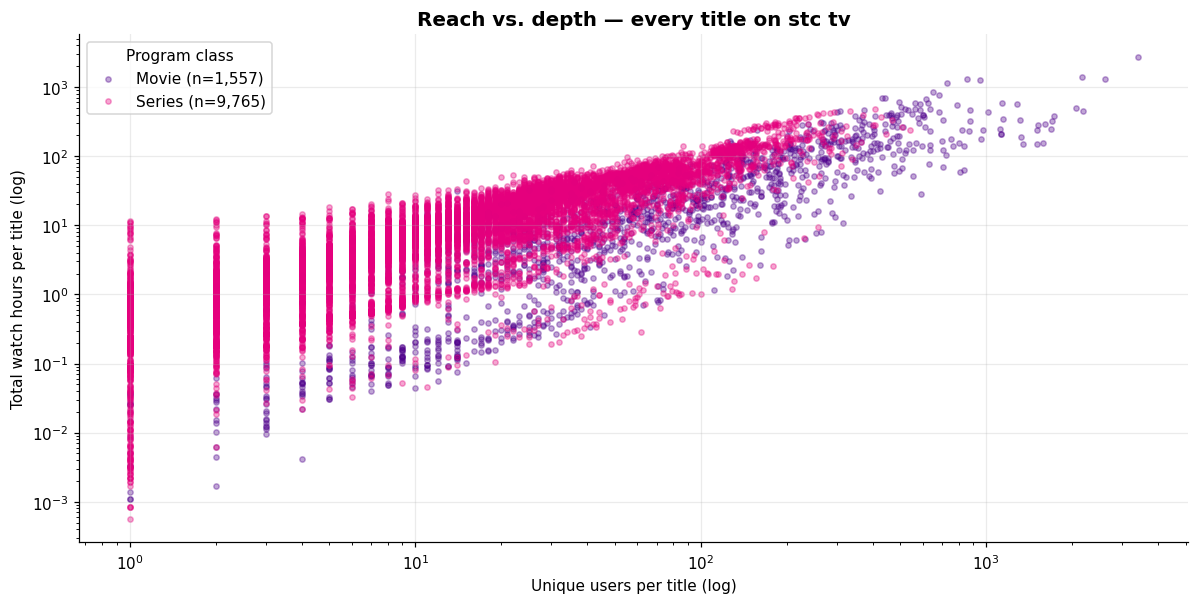

In [35]:
header("5.1 REACH vs. DEPTH BY TITLE", "الوصول مقابل العمق لكل عنوان")

title_level = (df_copy.groupby(["asset_key", "content_type"])
               .agg(total_views=("user_id_maped", "size"),
                    unique_users=("user_id_maped", "nunique"),
                    genre=("program_genre", lambda s: s.mode().iat[0]),
                    hd_share_pct=("hd", lambda s: s.mean() * 100))
               .join(valid_time.groupby(["asset_key", "content_type"])
                     .agg(total_watch_hours=("watch_hours", "sum"),
                          avg_minutes=("watch_minutes", "mean")))
               .reset_index())
title_level["hours_per_user"] = title_level.total_watch_hours / title_level.unique_users
title_level["views_per_user"] = title_level.total_views / title_level.unique_users
title_level = title_level.dropna(subset=["total_watch_hours"])

corr_all = title_level[["unique_users", "total_watch_hours"]].corr().iloc[0, 1]
corr_by_class = (title_level.groupby("content_type")
                 .apply(lambda g: g["unique_users"].corr(g["total_watch_hours"]))
                 .rename("corr(users, watch_hours)").to_frame().round(3))
print(f"Correlation between unique users and total watch hours (all titles): r = {corr_all:,.3f}")
show_table(corr_by_class, "Correlation by program class", save_as="12_reach_depth_corr")

show_table(title_level.groupby("content_type")[["hours_per_user", "views_per_user", "avg_minutes"]]
           .agg(["mean", "median"]).round(2),
           "Engagement intensity per title / كثافة التفاعل لكل عنوان", save_as="13_intensity_by_class")

# ---- Interactive scatter: Total Watch Time vs. Total Unique Users -------------------
scatter_src = title_level.nlargest(1500, "total_views")  # keep the plot readable & fast
fig = px.scatter(
    scatter_src, x="unique_users", y="total_watch_hours",
    color="content_type", size="total_views", size_max=38, opacity=0.72,
    color_discrete_map=CLASS_COLORS, hover_name="asset_key",
    hover_data={"genre": True, "avg_minutes": ":.1f", "hd_share_pct": ":.1f",
                "total_views": ":,", "unique_users": ":,", "total_watch_hours": ":,.0f"},
    log_x=True, log_y=True, trendline="ols", trendline_scope="trace",
    title="Customer experience: Total Watch Time vs. Total Unique Users (top 1,500 titles)",
    labels={"unique_users": "Unique users (log)", "total_watch_hours": "Total watch hours (log)",
            "content_type": "Class"})
fig.update_layout(height=620, legend_title_text="")
show_fig(fig)

# Static twin for slide decks / PDF export
fig, ax = plt.subplots(figsize=(11, 5.6))
for cls, grp in title_level.groupby("content_type"):
    ax.scatter(grp.unique_users, grp.total_watch_hours, s=12, alpha=0.35,
               color=CLASS_COLORS[cls], label=f"{cls} (n={len(grp):,})")
ax.set(xscale="log", yscale="log", xlabel="Unique users per title (log)",
       ylabel="Total watch hours per title (log)",
       title="Reach vs. depth — every title on stc tv")
ax.legend(title="Program class")
fig.tight_layout()
plt.show()


5.2 CONSUMPTION OVER TIME
استهلاك المحتوى عبر الزمن



▶ Monthly watch hours by class
content_type     Movie    Series
year_month                      
2017-03-01    6,773.00 11,702.00
2017-04-01   10,069.00 18,745.00
2017-05-01    8,116.00 17,903.00
2017-06-01    4,274.00  9,408.00
2017-07-01    7,070.00 14,130.00
2017-08-01    6,980.00 10,756.00
2017-09-01    5,105.00  9,956.00
2017-10-01    4,527.00 11,437.00
2017-11-01    6,820.00 20,267.00
2017-12-01    6,563.00 19,387.00
2018-01-01    5,933.00 17,706.00
2018-02-01    4,140.00 15,515.00
2018-03-01    4,223.00 15,623.00
2018-04-01    4,179.00 13,554.00


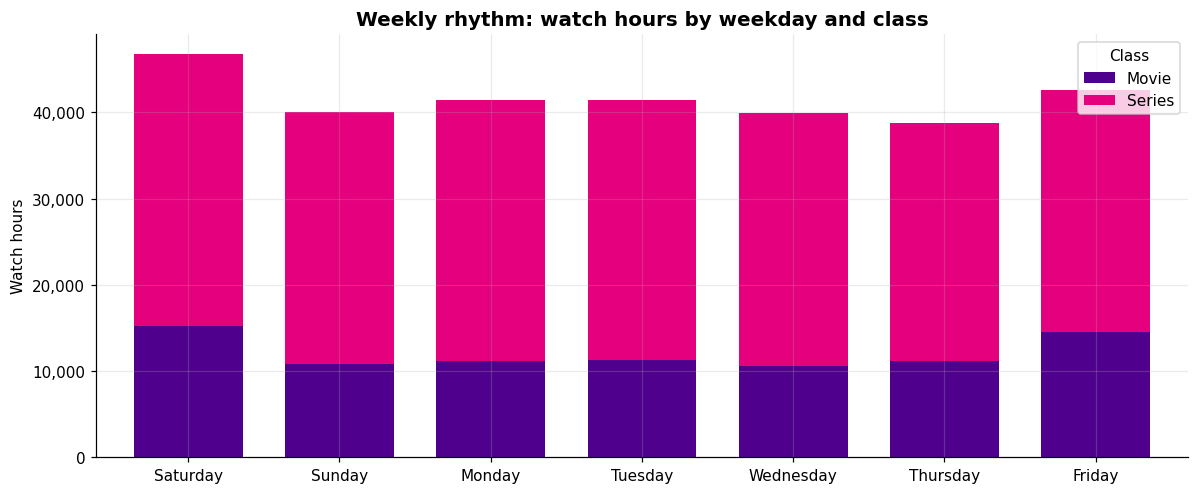

In [36]:
# ---- 5.2 Consumption over time (area chart) ----------------------------------------
header("5.2 CONSUMPTION OVER TIME", "استهلاك المحتوى عبر الزمن")
daily = (valid_time.groupby(["date", "content_type"])
         .agg(watch_hours=("watch_hours", "sum"),
              views=("user_id_maped", "size"),
              users=("user_id_maped", "nunique")).reset_index())

fig = px.area(daily, x="date", y="watch_hours", color="content_type",
              color_discrete_map=CLASS_COLORS,
              title="Daily watch time by program class — where the hours actually go",
              labels={"watch_hours": "Watch hours", "date": "", "content_type": "Class"})
fig.update_layout(height=460, hovermode="x unified", legend_title_text="")
show_fig(fig)

monthly = (valid_time.groupby(["year_month", "content_type"])
           .agg(watch_hours=("watch_hours", "sum"), views=("user_id_maped", "size"),
                active_users=("user_id_maped", "nunique")).reset_index())
show_table(monthly.pivot(index="year_month", columns="content_type", values="watch_hours")
           .round(0), "Monthly watch hours by class", save_as="14_monthly_watch_hours")

# Weekday rhythm — the scheduling lever for merchandising & push campaigns
order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
wk = (valid_time.groupby(["weekday", "content_type"])["watch_hours"].sum()
      .unstack().reindex(order))
fig, ax = plt.subplots(figsize=(11, 4.6))
wk.plot(kind="bar", stacked=True, ax=ax, color=[CLASS_COLORS[c] for c in wk.columns], width=0.72)
ax.set(title="Weekly rhythm: watch hours by weekday and class",
       xlabel="", ylabel="Watch hours")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(title="Class")
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

In [37]:
# ---- 5.3 Genre mix — what the catalogue is really used for --------------------------
header("5.3 GENRE PERFORMANCE", "أداء التصنيفات")
genre_tbl = (df_copy.groupby(["program_genre", "content_type"])
             .agg(total_views=("user_id_maped", "size"),
                  unique_users=("user_id_maped", "nunique"),
                  hd_share_pct=("hd", lambda s: s.mean() * 100))
             .join(valid_time.groupby(["program_genre", "content_type"])
                   .agg(total_watch_hours=("watch_hours", "sum"),
                        avg_minutes=("watch_minutes", "mean")))
             .reset_index().round(2))
show_table(genre_tbl.sort_values("total_views", ascending=False),
           "Genre × class performance", n=20, save_as="15_genre_performance")

fig = px.sunburst(genre_tbl.dropna(subset=["total_watch_hours"]),
                  path=["content_type", "program_genre"], values="total_watch_hours",
                  color="content_type", color_discrete_map=CLASS_COLORS,
                  title="Where stc tv watch time is concentrated: class → genre")
fig.update_layout(height=620)
show_fig(fig)


5.3 GENRE PERFORMANCE
أداء التصنيفات

▶ Genre × class performance
   program_genre content_type  total_views  unique_users  hd_share_pct  total_watch_hours  avg_minutes
4      Animation       Series       252501          2177         14.53          63,155.71        15.02
3      Animation        Movie       149229          8062         74.75          19,514.60         7.85
0         Action        Movie       111900          6937         63.85          28,539.47        15.33
14         Drama       Series       103739          2461          7.99          53,714.48        31.26
7         Comedy        Movie        69024          6261         56.91          13,625.58        11.86
8         Comedy       Series        67553          1826         32.34          24,814.58        22.18
1         Action       Series        62255          1952          6.48          32,455.55        31.48
13         Drama        Movie        51309          5823         75.77           7,747.29         9.07
17    

## 6. Video quality preference — HD vs. SD
### تفضيل جودة الفيديو: عالية الدقة مقابل العادية
Quality is both a **CX signal** (is the user getting the experience they want?) and a
**cost signal** (HD delivery is materially more expensive per hour of CDN traffic).
We answer three questions: how much of viewing is HD, *who* the SD viewers are,
and whether quality moves with program class, genre and engagement.

In [38]:
header("6.1 HD / SD SPLIT ACROSS THE PLATFORM", "توزيع الجودة على المنصة")
quality_tbl = (df_copy.groupby("quality")
               .agg(total_views=("user_id_maped", "size"),
                    unique_users=("user_id_maped", "nunique"),
                    distinct_assets=("asset_key", "nunique"),
                    bounce_rate_pct=("is_bounce", lambda s: s.mean() * 100))
               .join(valid_time.groupby("quality")
                     .agg(total_watch_hours=("watch_hours", "sum"),
                          avg_minutes=("watch_minutes", "mean"),
                          median_minutes=("watch_minutes", "median"))))
quality_tbl["share_of_views_%"] = quality_tbl.total_views / quality_tbl.total_views.sum() * 100
quality_tbl["share_of_watch_time_%"] = (quality_tbl.total_watch_hours
                                        / quality_tbl.total_watch_hours.sum() * 100)
show_table(quality_tbl.round(2).T, "HD vs. SD scorecard", save_as="16_quality_scorecard")

class_quality = pd.crosstab(df_copy.content_type, df_copy.quality, normalize="index") * 100
show_table(class_quality.round(2), "HD share by program class (% of views)", save_as="17_class_quality")

genre_quality = (pd.crosstab(df_copy.program_genre, df_copy.quality, normalize="index") * 100)
genre_volume = df_copy.program_genre.value_counts().rename("total_views")
genre_quality = (genre_quality.join(genre_volume).query("total_views >= 1000")
                 .sort_values("HD", ascending=False).round(2))
show_table(genre_quality, "HD share by genre (genres with >= 1,000 views)", save_as="18_genre_quality")


6.1 HD / SD SPLIT ACROSS THE PLATFORM
توزيع الجودة على المنصة

▶ HD vs. SD scorecard
quality                      HD         SD
total_views              405036     643539
unique_users              11000       6728
distinct_assets            1192      10351
bounce_rate_pct           32.77      24.04
total_watch_hours     72,670.90 218,190.20
avg_minutes               10.78      20.41
median_minutes             1.42      10.28
share_of_views_%          38.63      61.37
share_of_watch_time_%     24.98      75.02

▶ HD share by program class (% of views)
quality         HD    SD
content_type            
Movie        67.92 32.08
Series       13.08 86.92

▶ HD share by genre (genres with >= 1,000 views)
                 HD    SD  total_views
program_genre                         
Undefined     94.53  5.47         4751
Documentary   74.78 25.22        13291
Biography     71.99 28.01        16135
Crime         71.63 28.37         3232
Comedy        44.76 55.24       136577
Action        43.34

,HD,SD,total_views
program_genre,,,
Undefined,94.53,5.47,4751
Documentary,74.78,25.22,13291
Biography,71.99,28.01,16135
Crime,71.63,28.37,3232
Comedy,44.76,55.24,136577
Action,43.34,56.66,174155
Thriller,37.32,62.68,39601
Animation,36.90,63.10,401730
Horror,34.40,65.60,75306



6.2 DOES QUALITY CHANGE WATCH BEHAVIOUR?
هل تؤثر الجودة على سلوك المشاهدة؟
Median session - HD: 1.4 min | SD: 10.3 min
Mean   session - HD: 10.8 min | SD: 20.4 min
Mann-Whitney U (n=120,000 per group): p = 0 (significant at alpha=0.05), rank-biserial effect size = 0.330
Note: with samples this large, statistical significance is cheap - read the EFFECT SIZE, not the p-value, before acting on it.


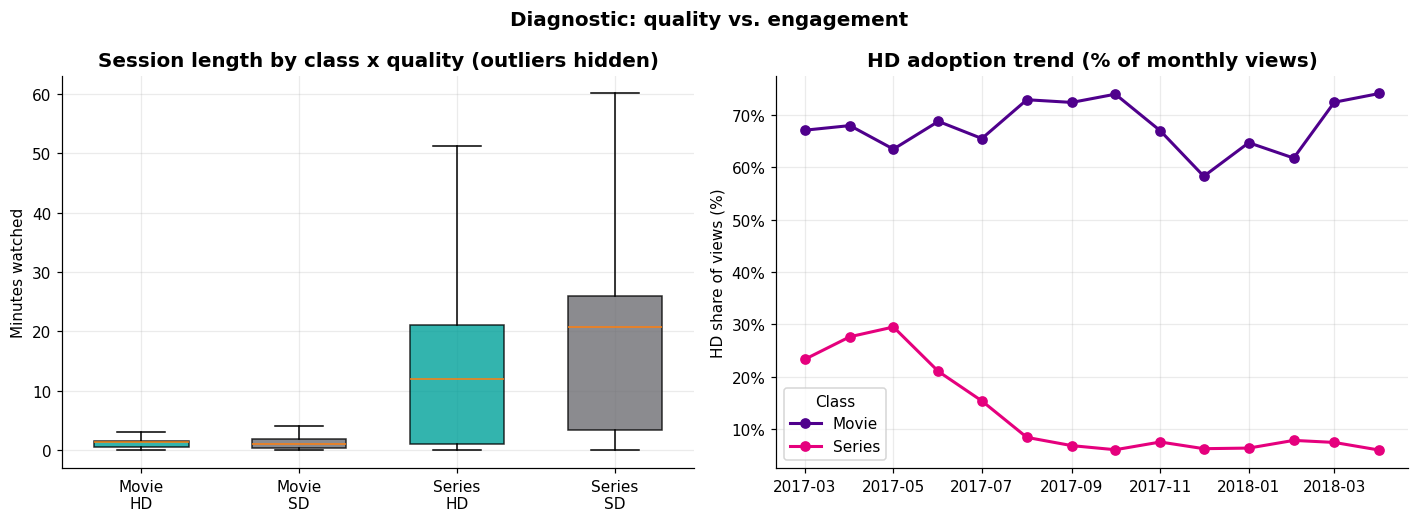

In [39]:
# ---- 6.2 Does quality change how long people watch? (diagnostic + significance) -----
header("6.2 DOES QUALITY CHANGE WATCH BEHAVIOUR?", "هل تؤثر الجودة على سلوك المشاهدة؟")
hd_min = valid_time.loc[valid_time.quality == "HD", "watch_minutes"]
sd_min = valid_time.loc[valid_time.quality == "SD", "watch_minutes"]
rng = np.random.default_rng(CONFIG["RANDOM_STATE"])
sample_n = min(120_000, len(hd_min), len(sd_min))  # Mann-Whitney on a large random sample
u_stat, p_u = stats.mannwhitneyu(rng.choice(hd_min.values, sample_n, replace=False),
                                 rng.choice(sd_min.values, sample_n, replace=False),
                                 alternative="two-sided")
rank_biserial = 1 - 2 * u_stat / (sample_n ** 2)
print(f"Median session - HD: {hd_min.median():,.1f} min | SD: {sd_min.median():,.1f} min")
print(f"Mean   session - HD: {hd_min.mean():,.1f} min | SD: {sd_min.mean():,.1f} min")
print(f"Mann-Whitney U (n={sample_n:,} per group): p = {p_u:.3g} "
      f"({'significant' if p_u < 0.05 else 'not significant'} at alpha=0.05), "
      f"rank-biserial effect size = {abs(rank_biserial):.3f}")
print("Note: with samples this large, statistical significance is cheap - read the EFFECT SIZE, "
      "not the p-value, before acting on it.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
box_data = [valid_time.loc[(valid_time.quality == q) & (valid_time.content_type == c), "watch_minutes"]
            for c in ["Movie", "Series"] for q in ["HD", "SD"]]
bp = axes[0].boxplot(box_data, tick_labels=["Movie\nHD", "Movie\nSD", "Series\nHD", "Series\nSD"],
                     showfliers=False, patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], [QUALITY_COLORS["HD"], QUALITY_COLORS["SD"]] * 2):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set(title="Session length by class x quality (outliers hidden)", ylabel="Minutes watched")

hd_trend = (df_copy.groupby([df_copy.year_month, "content_type"])["hd"].mean().unstack() * 100)
for cls in hd_trend.columns:
    axes[1].plot(hd_trend.index, hd_trend[cls], marker="o", lw=2,
                 color=CLASS_COLORS[cls], label=cls)
axes[1].set(title="HD adoption trend (% of monthly views)", ylabel="HD share of views (%)", xlabel="")
axes[1].legend(title="Class")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
fig.suptitle("Diagnostic: quality vs. engagement", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [40]:
# ---- 6.3 Viewer segmentation — who watches in SD? ----------------------------------
header("6.3 VIEWER SEGMENTS / تصنيف فئات المشاهدين")


def build_user_profiles(events: pd.DataFrame, timed: pd.DataFrame) -> pd.DataFrame:
    """One row per user: volume, depth, quality preference and content mix -> the UBA segment base."""
    prof = events.groupby("user_id_maped").agg(
        total_views=("asset_key", "size"),
        distinct_assets=("asset_key", "nunique"),
        active_days=("date", "nunique"),
        first_seen=("date", "min"),
        last_seen=("date", "max"),
        hd_views=("hd", "sum"),
        movie_views=("content_type", lambda s: (s == "Movie").sum()),
        genres_explored=("program_genre", "nunique"),
        bounce_rate=("is_bounce", "mean"),
    )
    prof = prof.join(timed.groupby("user_id_maped").agg(
        total_watch_hours=("watch_hours", "sum"),
        avg_minutes=("watch_minutes", "mean")))
    prof["total_watch_hours"] = prof["total_watch_hours"].fillna(0)
    prof["hd_share"] = prof.hd_views / prof.total_views
    prof["movie_share"] = prof.movie_views / prof.total_views
    prof["tenure_days"] = (prof.last_seen - prof.first_seen).dt.days + 1
    prof["views_per_active_day"] = prof.total_views / prof.active_days

    # --- Segment 1: video-quality preference -----------------------------------------
    prof["quality_segment"] = pd.cut(
        prof.hd_share, bins=[-0.001, 0.0001, 0.35, 0.65, 0.9999, 1.0],
        labels=["SD-Only", "SD-Leaning", "Balanced", "HD-Leaning", "HD-Only"])

    # --- Segment 2: engagement tier (data-driven quantile cut-offs) -------------------
    q = prof.total_watch_hours.quantile([0.5, 0.8, 0.95]).values
    prof["engagement_segment"] = pd.cut(
        prof.total_watch_hours, bins=[-0.001, q[0], q[1], q[2], np.inf],
        labels=["Light", "Regular", "Heavy", "Power"])

    # --- Segment 3: content preference ------------------------------------------------
    prof["content_segment"] = np.select(
        [prof.movie_share >= 0.65, prof.movie_share <= 0.35],
        ["Movie Lover", "Series Binger"], default="Mixed Viewer")
    return prof


users = build_user_profiles(df_copy, valid_time)
show_table(users[["total_views", "total_watch_hours", "distinct_assets", "active_days",
                  "hd_share", "movie_share", "avg_minutes"]].describe().round(2),
           "User-level profile distribution / توزيع خصائص المستخدمين", save_as="19_user_profiles")

seg_summary = (users.groupby("quality_segment", observed=True)
               .agg(users=("total_views", "size"),
                    avg_views=("total_views", "mean"),
                    avg_watch_hours=("total_watch_hours", "mean"),
                    avg_session_min=("avg_minutes", "mean"),
                    avg_active_days=("active_days", "mean"),
                    avg_distinct_assets=("distinct_assets", "mean"),
                    movie_share_pct=("movie_share", lambda s: s.mean() * 100),
                    bounce_pct=("bounce_rate", lambda s: s.mean() * 100)).round(2))
seg_summary["pct_of_users"] = (seg_summary.users / seg_summary.users.sum() * 100).round(2)
seg_summary["pct_of_watch_time"] = (users.groupby("quality_segment", observed=True)
                                    .total_watch_hours.sum()
                                    / users.total_watch_hours.sum() * 100).round(2)
show_table(seg_summary, "SD vs. HD viewer profiles / ملامح مشاهدي SD مقابل HD",
           save_as="20_quality_segments")

show_table(users.groupby("engagement_segment", observed=True)
           .agg(users=("total_views", "size"), avg_views=("total_views", "mean"),
                avg_watch_hours=("total_watch_hours", "mean"),
                hd_share_pct=("hd_share", lambda s: s.mean() * 100),
                movie_share_pct=("movie_share", lambda s: s.mean() * 100),
                avg_genres=("genres_explored", "mean")).round(2),
           "Engagement tiers / شرائح التفاعل", save_as="21_engagement_segments")

# Chi-square: is quality preference independent of content preference?
ct = pd.crosstab(users.quality_segment, users.content_segment)
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
show_table((ct / ct.values.sum() * 100).round(2),
           "Quality preference x content preference (% of all users)", save_as="22_segment_crosstab")
print(f"\nChi-square test of independence: chi2={chi2:,.1f}, dof={dof}, p={p_chi:.3g}, "
      f"Cramers V={cramers_v:.3f} -> quality preference and content preference are "
      f"{'NOT independent' if p_chi < 0.05 else 'independent'}.")


6.3 VIEWER SEGMENTS / تصنيف فئات المشاهدين

▶ User-level profile distribution / توزيع خصائص المستخدمين
       total_views  total_watch_hours  distinct_assets  active_days  hd_share  movie_share  avg_minutes
count    11,578.00          11,578.00        11,578.00    11,578.00 11,578.00    11,578.00    11,572.00
mean         90.57              25.12            42.06        14.33      0.70         0.83         9.64
std         231.46              81.90            99.83        29.18      0.34         0.31        17.83
min           1.00               0.00             1.00         1.00      0.00         0.00         0.03
25%           3.00               0.04             2.00         1.00      0.43         0.85         0.84
50%          11.00               0.36             6.00         4.00      0.86         1.00         1.45
75%          57.00               8.49            30.00        13.00      1.00         1.00        13.39
max       2,169.00           1,293.97         1,150.00       296

In [41]:
# ---- 6.4 Segment visualisations ----------------------------------------------------
heat = (users.pivot_table(index="engagement_segment", columns="quality_segment",
                          values="total_watch_hours", aggfunc="mean", observed=True).round(1))
fig = px.imshow(heat, text_auto=True, aspect="auto", color_continuous_scale="Purples",
                title="Average watch hours per user - engagement tier x quality preference",
                labels={"x": "Quality preference", "y": "Engagement tier", "color": "Avg hours"})
fig.update_layout(height=430)
show_fig(fig)

seg_counts = (users.groupby(["quality_segment", "content_segment"], observed=True)
              .size().rename("users").reset_index())
fig = px.bar(seg_counts, x="quality_segment", y="users", color="content_segment",
             barmode="group", color_discrete_sequence=PALETTE,
             title="Viewer segments: quality preference x content preference",
             labels={"quality_segment": "Quality preference", "users": "Users",
                     "content_segment": "Content preference"})
fig.update_layout(height=470, legend_title_text="")
show_fig(fig)

cq = (df_copy.groupby(["content_type", "quality"]).size().rename("views").reset_index())
fig = px.bar(cq, x="content_type", y="views", color="quality", barmode="group",
             color_discrete_map=QUALITY_COLORS, text_auto=".2s",
             title="Views by program class and video quality",
             labels={"content_type": "", "views": "Total views", "quality": "Quality"})
fig.update_layout(height=430, legend_title_text="")
show_fig(fig)

## 7. Predictive analytics
### التحليل التنبؤي
Two forward-looking models, both trained and validated on a hold-out period:
1. **Demand forecast** — daily watch hours for the next 14 days (capacity & merchandising planning).
2. **Churn-risk model** — which active users are about to go silent (retention campaigns).

Both are deliberately simple, transparent baselines: in a production stc tv stack they become the
starting point that a gradient-boosted or sequence model must beat.

In [42]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

header("7.1 DEMAND FORECAST - DAILY WATCH HOURS", "التنبؤ بالطلب: ساعات المشاهدة اليومية")

ts = (valid_time.groupby("date")["watch_hours"].sum().asfreq("D").fillna(0).rename("watch_hours"))
ts_df = ts.to_frame()
ts_df["t"] = np.arange(len(ts_df))                       # linear trend
ts_df["dow"] = ts_df.index.dayofweek                     # weekly seasonality
feat = pd.get_dummies(ts_df[["t", "dow"]], columns=["dow"], drop_first=True).astype(float)

HOLDOUT = 30
X_tr, X_te = feat.iloc[:-HOLDOUT], feat.iloc[-HOLDOUT:]
y_tr, y_te = ts_df.watch_hours.iloc[:-HOLDOUT], ts_df.watch_hours.iloc[-HOLDOUT:]

demand_model = LinearRegression().fit(X_tr, y_tr)
pred_te = demand_model.predict(X_te)
mape = mean_absolute_percentage_error(y_te, pred_te) * 100
r2 = demand_model.score(X_tr, y_tr)

# Refit on the full series, then project the next 14 days
demand_model_full = LinearRegression().fit(feat, ts_df.watch_hours)
future_idx = pd.date_range(ts_df.index.max() + timedelta(days=1), periods=14, freq="D")
future = pd.DataFrame({"t": np.arange(len(ts_df), len(ts_df) + 14), "dow": future_idx.dayofweek},
                      index=future_idx)
future = pd.get_dummies(future, columns=["dow"], drop_first=True).astype(float)
future = future.reindex(columns=feat.columns, fill_value=0.0)
forecast = pd.Series(demand_model_full.predict(future), index=future_idx, name="forecast_hours")

trend_per_day = demand_model_full.coef_[list(feat.columns).index("t")]
print(f"Trend / الاتجاه العام        : {trend_per_day:+,.1f} watch hours per day "
      f"({trend_per_day*30:+,.0f} h per month)")
print(f"Hold-out accuracy (last {HOLDOUT} days): MAPE = {mape:,.1f}%  |  in-sample R2 = {r2:,.3f}")
print(f"Next 14 days forecast        : {forecast.sum():,.0f} watch hours "
      f"({forecast.mean():,.0f} h/day on average)")
print("Read R2 with care: calendar features alone explain little day-to-day variance because "
      "volume is driven by title releases and campaigns, which this dataset does not expose. "
      "The 14-day numbers are therefore a planning BASELINE, not a committed prediction.")
show_table(forecast.round(0).to_frame(), "14-day watch-hour forecast", save_as="23_demand_forecast")

fig = go.Figure()
fig.add_trace(go.Scatter(x=ts_df.index, y=ts_df.watch_hours, name="Actual",
                         line=dict(color=STC_PURPLE, width=1.4)))
fig.add_trace(go.Scatter(x=ts_df.index, y=ts_df.watch_hours.rolling(7).mean(),
                         name="7-day moving average", line=dict(color=STC_TEAL, width=2.6)))
fig.add_trace(go.Scatter(x=forecast.index, y=forecast.values, name="14-day forecast",
                         line=dict(color=STC_MAGENTA, width=2.6, dash="dash")))
fig.update_layout(title="Predictive: daily watch hours with a 14-day forecast",
                  xaxis_title="", yaxis_title="Watch hours", height=470, hovermode="x unified")
show_fig(fig)


7.1 DEMAND FORECAST - DAILY WATCH HOURS
التنبؤ بالطلب: ساعات المشاهدة اليومية
Trend / الاتجاه العام        : -0.4 watch hours per day (-11 h per month)
Hold-out accuracy (last 30 days): MAPE = 10.9%  |  in-sample R2 = 0.064
Next 14 days forecast        : 8,729 watch hours (624 h/day on average)
Read R2 with care: calendar features alone explain little day-to-day variance because volume is driven by title releases and campaigns, which this dataset does not expose. The 14-day numbers are therefore a planning BASELINE, not a committed prediction.

▶ 14-day watch-hour forecast
            forecast_hours
2018-05-01          623.00
2018-05-02          596.00
2018-05-03          578.00
2018-05-04          643.00
2018-05-05          713.00
2018-05-06          599.00
2018-05-07          622.00
2018-05-08          620.00
2018-05-09          594.00
2018-05-10          576.00
2018-05-11          640.00
2018-05-12          710.00
2018-05-13          596.00
2018-05-14          620.00


In [43]:
# ---- 7.2 Churn-risk model ----------------------------------------------------------
header("7.2 CHURN-RISK MODEL", "نموذج توقع هجر المستخدمين")

CHURN_WINDOW = 30  # days of silence at the end of the period = churned
cutoff = df_copy["date"].max() - timedelta(days=CHURN_WINDOW)
obs = df_copy[df_copy["date"] <= cutoff]          # feature window
outcome = df_copy[df_copy["date"] > cutoff]       # label window
print(f"Feature window : {obs['date'].min():%Y-%m-%d} -> {cutoff:%Y-%m-%d}")
print(f"Outcome window : {(cutoff + timedelta(days=1)):%Y-%m-%d} -> {df_copy['date'].max():%Y-%m-%d} "
      f"({CHURN_WINDOW} days)")

churn_base = build_user_profiles(obs, valid_time[valid_time["date"] <= cutoff])
churn_base["recency_days"] = (cutoff - churn_base["last_seen"]).dt.days
churn_base["churned"] = (~churn_base.index.isin(outcome["user_id_maped"].unique())).astype(int)
print(f"Users in scope : {len(churn_base):,}  |  churn rate in the outcome window: "
      f"{churn_base.churned.mean()*100:,.1f}%")

print("The base rate is high by design: most accounts in this extract are one-off/light users, "
      "so 'churn' here means '30 days of silence', not contract cancellation.")

FEATURES = ["recency_days", "total_views", "total_watch_hours", "distinct_assets", "active_days",
            "avg_minutes", "hd_share", "movie_share", "genres_explored", "views_per_active_day",
            "tenure_days", "bounce_rate"]
model_df = churn_base[FEATURES + ["churned"]].replace([np.inf, -np.inf], np.nan).fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    model_df[FEATURES], model_df["churned"], test_size=0.25,
    random_state=CONFIG["RANDOM_STATE"], stratify=model_df["churned"])

logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,
                                                           random_state=CONFIG["RANDOM_STATE"]))
logit.fit(X_train, y_train)
gbm = GradientBoostingClassifier(random_state=CONFIG["RANDOM_STATE"]).fit(X_train, y_train)

auc_logit = roc_auc_score(y_test, logit.predict_proba(X_test)[:, 1])
auc_gbm = roc_auc_score(y_test, gbm.predict_proba(X_test)[:, 1])
print(f"\nROC-AUC  logistic regression : {auc_logit:,.3f}")
print(f"ROC-AUC  gradient boosting   : {auc_gbm:,.3f}")
best_model, best_name = (gbm, "Gradient Boosting") if auc_gbm >= auc_logit else (logit, "Logistic Regression")
print(f"Selected model: {best_name}\n")
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=["Retained", "Churned"], digits=3))

drivers = (pd.Series(logit[-1].coef_[0], index=FEATURES)
           .sort_values(key=abs, ascending=False).round(3).to_frame("std_coefficient"))
drivers["direction"] = np.where(drivers.std_coefficient > 0, "raises churn risk", "protects retention")
show_table(drivers, "Churn drivers (standardised logistic coefficients)", save_as="24_churn_drivers")

churn_base["churn_probability"] = best_model.predict_proba(model_df[FEATURES])[:, 1]
churn_base["risk_band"] = pd.cut(churn_base.churn_probability, [-0.01, 0.3, 0.6, 0.8, 1.0],
                                 labels=["Low", "Medium", "High", "Critical"])
risk_tbl = (churn_base.groupby("risk_band", observed=True)
            .agg(users=("churn_probability", "size"),
                 actual_churn_rate_pct=("churned", lambda s: s.mean() * 100),
                 avg_watch_hours=("total_watch_hours", "mean"),
                 avg_views=("total_views", "mean"),
                 hd_share_pct=("hd_share", lambda s: s.mean() * 100)).round(2))
risk_tbl["watch_hours_at_risk"] = (churn_base.groupby("risk_band", observed=True)
                                   .total_watch_hours.sum().round(0))
show_table(risk_tbl, "Churn-risk bands / شرائح مخاطر الهجر", save_as="25_churn_risk_bands")

at_risk_value = churn_base.loc[churn_base.risk_band.isin(["High", "Critical"]), "total_watch_hours"].sum()
print(f"\nWatch time sitting in High/Critical risk bands: {at_risk_value:,.0f} hours "
      f"({at_risk_value / churn_base.total_watch_hours.sum() * 100:,.1f}% of engagement in scope)")

fig = px.histogram(churn_base, x="churn_probability", color="risk_band", nbins=50,
                   color_discrete_sequence=[STC_TEAL, "#FF9E1B", STC_MAGENTA, "#B00020"],
                   category_orders={"risk_band": ["Low", "Medium", "High", "Critical"]},
                   title="Predictive: distribution of churn probability across the user base",
                   labels={"churn_probability": "Predicted churn probability", "count": "Users",
                           "risk_band": "Risk band"})
fig.update_layout(height=430)
show_fig(fig)


7.2 CHURN-RISK MODEL
نموذج توقع هجر المستخدمين
Feature window : 2017-03-14 -> 2018-03-31
Outcome window : 2018-04-01 -> 2018-04-30 (30 days)
Users in scope : 11,342  |  churn rate in the outcome window: 79.1%
The base rate is high by design: most accounts in this extract are one-off/light users, so 'churn' here means '30 days of silence', not contract cancellation.

ROC-AUC  logistic regression : 0.878
ROC-AUC  gradient boosting   : 0.888
Selected model: Gradient Boosting

              precision    recall  f1-score   support

    Retained      0.758     0.576     0.655       592
     Churned      0.895     0.951     0.922      2244

    accuracy                          0.873      2836
   macro avg      0.826     0.764     0.788      2836
weighted avg      0.866     0.873     0.866      2836


▶ Churn drivers (standardised logistic coefficients)
                      std_coefficient           direction
recency_days                     1.50   raises churn risk
active_days             

In [44]:
# ---- 7.3 HD-propensity: which viewing occasions choose HD? -------------------------
header("7.3 HD-PROPENSITY MODEL", "نموذج تفضيل الجودة العالية")
hd_sample = df_copy.sample(min(200_000, len(df_copy)), random_state=CONFIG["RANDOM_STATE"])
hd_X = pd.get_dummies(
    hd_sample[["content_type", "program_genre", "is_weekend", "watch_minutes", "season"]]
    .assign(watch_minutes=lambda d: np.log1p(d.watch_minutes.clip(upper=600)),
            season=lambda d: d.season.fillna(0).astype(int)),
    columns=["content_type", "program_genre"], drop_first=True).astype(float)
hd_y = hd_sample["hd"].astype(int)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(hd_X, hd_y, test_size=0.25,
                                              random_state=CONFIG["RANDOM_STATE"], stratify=hd_y)
hd_model = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=CONFIG["RANDOM_STATE"]))
hd_model.fit(Xh_tr, yh_tr)
print(f"HD-choice model ROC-AUC: {roc_auc_score(yh_te, hd_model.predict_proba(Xh_te)[:, 1]):,.3f}")
hd_drivers = (pd.Series(hd_model[-1].coef_[0], index=hd_X.columns)
              .sort_values(key=abs, ascending=False).head(12).round(3).to_frame("std_coefficient"))
hd_drivers["effect"] = np.where(hd_drivers.std_coefficient > 0, "pushes towards HD", "pushes towards SD")
show_table(hd_drivers, "What predicts an HD play? (top 12 standardised coefficients)",
           save_as="26_hd_drivers")


7.3 HD-PROPENSITY MODEL
نموذج تفضيل الجودة العالية
HD-choice model ROC-AUC: 0.825

▶ What predicts an HD play? (top 12 standardised coefficients)
                           std_coefficient             effect
content_type_Series                  -1.15  pushes towards SD
season                               -0.29  pushes towards SD
program_genre_Animation               0.24  pushes towards HD
program_genre_Comedy                  0.19  pushes towards HD
program_genre_Undefined               0.19  pushes towards HD
program_genre_Documentary             0.17  pushes towards HD
program_genre_Family                 -0.13  pushes towards SD
watch_minutes                        -0.13  pushes towards SD
program_genre_Romance                -0.08  pushes towards SD
program_genre_Drama                   0.08  pushes towards HD
program_genre_Crime                   0.07  pushes towards HD
program_genre_Thriller               -0.06  pushes towards SD


,std_coefficient,effect
content_type_Series,-1.15,pushes towards SD
season,-0.29,pushes towards SD
program_genre_Animation,0.24,pushes towards HD
program_genre_Comedy,0.19,pushes towards HD
program_genre_Undefined,0.19,pushes towards HD
program_genre_Documentary,0.17,pushes towards HD
program_genre_Family,-0.13,pushes towards SD
watch_minutes,-0.13,pushes towards SD
program_genre_Romance,-0.08,pushes towards SD
program_genre_Drama,0.08,pushes towards HD


## 8. Operational & security anomaly watchlist (UBA)
### رصد الشذوذ التشغيلي والأمني
UBA is not only about taste — the same event log exposes stuck streams, credential sharing and
scripted/bot-like access. These users are flagged for the platform and fraud teams, never
auto-punished: the output is a watchlist, not a verdict.

In [45]:
header("8. ANOMALY WATCHLIST", "قائمة المراقبة للحالات الشاذة")

daily_user = df_copy.groupby(["user_id_maped", "date"]).agg(
    plays=("asset_key", "size"), hours=("watch_hours", "sum"))
p999_plays = daily_user.plays.quantile(0.999)

anomaly_users = pd.DataFrame({
    "max_plays_in_a_day": daily_user.groupby("user_id_maped").plays.max(),
    "max_hours_in_a_day": daily_user.groupby("user_id_maped").hours.max(),
    "stuck_sessions_over_12h": df_copy.groupby("user_id_maped").is_implausible.sum(),
    "bounce_rate_pct": (df_copy.groupby("user_id_maped").is_bounce.mean() * 100).round(1),
    "total_views": df_copy.groupby("user_id_maped").size(),
})
anomaly_users["anomaly_flags"] = (
    (anomaly_users.max_plays_in_a_day > p999_plays).astype(int)
    + (anomaly_users.max_hours_in_a_day > 24).astype(int)          # >24h of playback in one day
    + (anomaly_users.stuck_sessions_over_12h >= 5).astype(int)
    + ((anomaly_users.bounce_rate_pct > 90) & (anomaly_users.total_views > 100)).astype(int))
watchlist = (anomaly_users[anomaly_users["anomaly_flags"] >= 2]
             .sort_values(["anomaly_flags", "max_hours_in_a_day"], ascending=False).round(2))
print(f"Daily-plays 99.9th percentile threshold : {p999_plays:,.0f} plays/day")
print(f"Users raising 2+ anomaly flags          : {len(watchlist):,} "
      f"({len(watchlist)/df_copy.user_id_maped.nunique()*100:,.2f}% of the base)")
show_table(watchlist, "Anomaly watchlist (top 15) / قائمة المراقبة", n=15, save_as="27_anomaly_watchlist")
print("\nLikely explanations, in order of probability: a TV left switched on (stuck stream), "
      "one account shared across a household or beyond it, or scripted access. "
      "Route to Platform Ops first, Fraud second.")


8. ANOMALY WATCHLIST
قائمة المراقبة للحالات الشاذة
Daily-plays 99.9th percentile threshold : 154 plays/day
Users raising 2+ anomaly flags          : 128 (1.11% of the base)

▶ Anomaly watchlist (top 15) / قائمة المراقبة
               max_plays_in_a_day  max_hours_in_a_day  stuck_sessions_over_12h  bounce_rate_pct  total_views  anomaly_flags
user_id_maped                                                                                                              
23162                         510              242.51                        8            30.00         1538              3
7565                          399               48.73                       12            13.60         1815              3
28542                          18              319.20                       41            13.20          424              2
31985                          18              207.94                        8            32.10          333              2
26927                          37  

## 9. Data storytelling — diagnostic findings & prescriptive actions
### السرد القصصي للبيانات: النتائج التشخيصية والتوصيات
Every number below is computed live from the dataset, so the narrative stays true after any
refresh of the source file.

In [46]:
header("9.1 DIAGNOSTIC FINDINGS - WHY THE NUMBERS LOOK LIKE THIS", "النتائج التشخيصية")

movie_row, series_row = class_tbl.loc["Movie"], class_tbl.loc["Series"]
sd_users_pct = seg_summary.loc[["SD-Only", "SD-Leaning"], "pct_of_users"].sum()
sd_time_pct = seg_summary.loc[["SD-Only", "SD-Leaning"], "pct_of_watch_time"].sum()
top20_share = (title_level.nlargest(int(len(title_level) * 0.2), "total_views").total_views.sum()
               / title_level.total_views.sum() * 100)
weekend_lift = (valid_time.groupby("is_weekend").watch_hours.mean().pipe(lambda s: s[True] / s[False] - 1) * 100)
top_genre = genre_tbl.groupby("program_genre").total_watch_hours.sum().idxmax()
top_genre_share = (genre_tbl.groupby("program_genre").total_watch_hours.sum().max()
                   / genre_tbl.total_watch_hours.sum() * 100)

FINDINGS = [
    ("Series drive volume, movies drive reach-per-title",
     f"Series take {series_row['share_of_views_%']:.1f}% of views and "
     f"{series_row['share_of_watch_time_%']:.1f}% of watch time, at "
     f"{series_row['views_per_user']:.1f} views per user vs. {movie_row['views_per_user']:.1f} for movies. "
     f"Episodic structure - not superior content - is what multiplies the session count."),
    ("Median session is far below the mean",
     f"Mean {valid_time.watch_minutes.mean():.1f} min vs. median {valid_time.watch_minutes.median():.1f} min, "
     f"with {df_copy.is_bounce.mean()*100:.1f}% of plays under {CONFIG['BOUNCE_SECONDS']}s. "
     f"Most 'views' are browsing, not watching - the discovery journey is the bottleneck."),
    ("A minority of the catalogue carries the platform",
     f"The top 20% of titles absorb {top20_share:.1f}% of all views. Long-tail licensing spend "
     f"is not returning proportional engagement."),
    ("SD is still a large, valuable segment",
     f"{sd_users_pct:.1f}% of users are SD-only or SD-leaning and they account for "
     f"{sd_time_pct:.1f}% of watch time. Overall HD share of views is {df_copy.hd.mean()*100:.1f}%, "
     f"but only {class_quality.loc['Series','HD']:.1f}% of series views are HD vs. "
     f"{class_quality.loc['Movie','HD']:.1f}% for movies - an availability gap in the series "
     f"catalogue, not only a bandwidth choice."),
    ("Genre concentration",
     f"'{top_genre}' alone accounts for {top_genre_share:.1f}% of total watch time - "
     f"strong product-market fit, but also concentration risk if that supply deal changes."),
    ("Weekend and stuck-stream effects distort raw reporting",
     f"Weekend sessions run {weekend_lift:+.1f}% longer than weekdays, and "
     f"{df_copy.is_implausible.sum():,} sessions over {CONFIG['MAX_PLAUSIBLE_SESSION_HOURS']}h "
     f"would otherwise inflate watch time by a large margin. Both must be handled before any "
     f"period-over-period comparison is trusted."),
]
for i, (title, detail) in enumerate(FINDINGS, 1):
    print(f"\n[{i}] {title}\n" + textwrap.fill(detail, 92, initial_indent="    ", subsequent_indent="    "))


9.1 DIAGNOSTIC FINDINGS - WHY THE NUMBERS LOOK LIKE THIS
النتائج التشخيصية

[1] Series drive volume, movies drive reach-per-title
    Series take 53.4% of views and 70.8% of watch time, at 143.6 views per user vs. 43.0 for
    movies. Episodic structure - not superior content - is what multiplies the session
    count.

[2] Median session is far below the mean
    Mean 16.7 min vs. median 1.9 min, with 27.4% of plays under 60s. Most 'views' are
    browsing, not watching - the discovery journey is the bottleneck.

[3] A minority of the catalogue carries the platform
    The top 20% of titles absorb 77.5% of all views. Long-tail licensing spend is not
    returning proportional engagement.

[4] SD is still a large, valuable segment
    21.5% of users are SD-only or SD-leaning and they account for 70.2% of watch time.
    Overall HD share of views is 38.6%, but only 13.1% of series views are HD vs. 67.9% for
    movies - an availability gap in the series catalogue, not only a bandwidth 

In [47]:
header("9.2 PRESCRIPTIVE RECOMMENDATIONS - WHAT stc tv SHOULD DO NEXT", "التوصيات الإجرائية")

ACTIONS = [
    ("Rebuild the home rail around episodic momentum", "Content & Product",
     f"Series generate {series_row['views_per_user']:.1f} views/user. Promote 'continue watching' and "
     f"next-episode autoplay above hero banners for the {int((users.content_segment=='Series Binger').sum()):,} "
     f"Series Bingers, and seed movie-lovers with franchise/series entry points.",
     "Target: +10-15% sessions per active user within one quarter."),
    ("Attack the bounce rate with better discovery", "Product / Recommendations",
     f"{df_copy.is_bounce.mean()*100:.1f}% of plays end under {CONFIG['BOUNCE_SECONDS']}s. Add trailer-on-hover, "
     f"a 'because you watched' rail trained on the {df_copy.asset_key.nunique():,} asset catalogue, "
     f"and rank by predicted completion instead of popularity.",
     "Target: bounce rate down 5pp = a measurable lift in true watch time."),
    ("Rationalise long-tail licensing", "Content Acquisition",
     f"Top 20% of titles = {top20_share:.1f}% of views. Re-negotiate or drop the bottom decile at renewal and "
     f"redirect the budget into the '{top_genre}' and top-performing series franchises.",
     "Target: flat engagement at lower content cost - direct margin gain."),
    ("Close the HD gap on series", "Content Ops / Encoding",
     f"Series HD share is {class_quality.loc['Series','HD']:.1f}% vs. {class_quality.loc['Movie','HD']:.1f}% "
     f"for movies. Audit the top {CONFIG['TOP_N']} shows for missing HD renditions and re-encode; "
     f"where the ceiling is the user's connection, ship adaptive-bitrate messaging instead of a silent downgrade.",
     "Target: raise series HD share, protect perceived quality for premium tiers."),
    ("Monetise the quality segments differently", "Pricing / Marketing",
     f"{sd_users_pct:.1f}% of users are SD-first yet contribute {sd_time_pct:.1f}% of watch time. Offer them a "
     f"cheaper data-light tier, and upsell HD/4K to the "
     f"{int((users.quality_segment=='HD-Only').sum()):,} HD-only users who already show willingness to consume premium.",
     "Target: ARPU growth without pushing price-sensitive users to churn."),
    ("Run the churn model weekly against retention campaigns", "CRM / Retention",
     f"{best_name} scores AUC {max(auc_logit, auc_gbm):.3f}; High/Critical bands hold "
     f"{at_risk_value:,.0f} watch hours. Trigger a personalised 'next episode' push for users "
     f"whose recency exceeds 14 days before they cross the 30-day silence line.",
     "Target: recover a share of at-risk engagement; measure with a hold-out control group."),
    ("Schedule merchandising to the weekly rhythm", "Marketing Ops",
     f"Weekend sessions run {weekend_lift:+.1f}% longer. Land new-episode drops and push campaigns just "
     f"before the weekend peak rather than spreading them evenly across the week.",
     "Target: higher campaign conversion at identical spend."),
    ("Instrument the log before the next analysis cycle", "Data Engineering",
     f"Day-level timestamps, a missing leading 'S' in title strings, {dup_mask.sum():,} duplicate rows and "
     f"{df_copy.is_implausible.sum():,} stuck sessions all cap analytical precision. Capture event-level "
     f"timestamps, device, and content duration so completion rate becomes computable.",
     "Target: completion rate and true retention curves - today they cannot be measured."),
]
for i, (action, owner, rationale, impact) in enumerate(ACTIONS, 1):
    print(f"\n[{i}] {action}   | owner: {owner}")
    print(textwrap.fill(rationale, 92, initial_indent="    Why: ", subsequent_indent="         "))
    print(textwrap.fill(impact, 92, initial_indent="    KPI: ", subsequent_indent="         "))

print("\n" + "-" * 92)
print(textwrap.fill(
    "Caveats a decision-maker should know: the log covers "
    f"{df_copy['date'].min():%b %Y} to {df_copy['date'].max():%b %Y} at day granularity and stops at the "
    "1,048,575-row Excel sheet limit, so it is a truncated extract rather than the full population; "
    "there is no content-duration field, so completion rate is unavailable and 'views' cannot be "
    "normalised by runtime; and user_id is device/account-level, so household sharing is invisible.",
    92))


9.2 PRESCRIPTIVE RECOMMENDATIONS - WHAT stc tv SHOULD DO NEXT
التوصيات الإجرائية

[1] Rebuild the home rail around episodic momentum   | owner: Content & Product
    Why: Series generate 143.6 views/user. Promote 'continue watching' and next-episode
         autoplay above hero banners for the 1,571 Series Bingers, and seed movie-lovers
         with franchise/series entry points.
    KPI: Target: +10-15% sessions per active user within one quarter.

[2] Attack the bounce rate with better discovery   | owner: Product / Recommendations
    Why: 27.4% of plays end under 60s. Add trailer-on-hover, a 'because you watched' rail
         trained on the 11,324 asset catalogue, and rank by predicted completion instead of
         popularity.
    KPI: Target: bounce rate down 5pp = a measurable lift in true watch time.

[3] Rationalise long-tail licensing   | owner: Content Acquisition
    Why: Top 20% of titles = 77.5% of views. Re-negotiate or drop the bottom decile at
         renewal and r

In [48]:
# ---- 9.3 Export every deliverable ---------------------------------------------------
header("9.3 EXPORTS", "الملفات المُصدَّرة")

if CONFIG["EXPORT_RESULTS"]:
    out_dir = CONFIG["OUTPUT_DIR"]

    # (a) Named deliverables requested by the business
    export_cols = ["date", "user_id_maped", "content_type", "program_class", "show_name",
                   "clean_title", "asset_key", "episode_code", "season", "episode",
                   "program_genre", "quality", "hd", "duration_seconds", "watch_minutes",
                   "watch_hours", "play_level", "is_bounce", "is_implausible", "weekday",
                   "is_weekend"]
    # The three headline deliverables sit NEXT TO THE NOTEBOOK for easy pickup;
    # every other table goes into ./outputs to keep the working folder readable.
    df_copy[export_cols].to_csv("stc_cleaned_data.csv", index=False, encoding="utf-8-sig")
    top_movies.to_csv("top10_movies.csv", encoding="utf-8-sig")
    top_shows.to_csv("top10_series.csv", encoding="utf-8-sig")
    top_episodes.to_csv(os.path.join(out_dir, "top10_series_episodes.csv"), encoding="utf-8-sig")
    users.to_csv(os.path.join(out_dir, "user_segments.csv"), encoding="utf-8-sig")
    churn_base[["churn_probability", "risk_band", "churned", "recency_days", "total_views",
                "total_watch_hours"]].to_csv(os.path.join(out_dir, "churn_scores.csv"),
                                             encoding="utf-8-sig")

    # (b) Every analytical table collected through the notebook
    for name, table in RESULT_TABLES.items():
        table.to_csv(os.path.join(out_dir, f"{name}.csv"), encoding="utf-8-sig")

    # (c) One workbook a stakeholder can open without touching Python
    with pd.ExcelWriter(os.path.join(out_dir, "stc_tv_analysis_report.xlsx"), engine="openpyxl") as xl:
        for name, table in RESULT_TABLES.items():
            table.to_excel(xl, sheet_name=name[:31])

    print("Headline deliverables (notebook folder):")
    for f in ["stc_cleaned_data.csv", "top10_movies.csv", "top10_series.csv"]:
        print(f"  {f:<42} {os.path.getsize(f)/1e6:>8,.2f} MB")
    print(f"\nSupporting tables (./{out_dir}/):")
    for f in sorted(os.listdir(out_dir)):
        print(f"  {f:<42} {os.path.getsize(os.path.join(out_dir, f))/1e6:>8,.2f} MB")
else:
    print("EXPORT_RESULTS is False - nothing written to disk.")

header("ANALYSIS COMPLETE / اكتمل التحليل")
print(f"{fmt_int(total_views)} viewing events | {fmt_int(total_users)} users | "
      f"{fmt_hours(total_hours)} of watch time analysed across "
      f"{df_copy.asset_key.nunique():,} distinct assets.")


9.3 EXPORTS
الملفات المُصدَّرة
Headline deliverables (notebook folder):
  stc_cleaned_data.csv                         203.28 MB
  top10_movies.csv                               0.00 MB
  top10_series.csv                               0.00 MB

Supporting tables (./outputs/):
  01_schema.csv                                  0.00 MB
  02_missing_values.csv                          0.00 MB
  03_summary_clean.csv                           0.00 MB
  03_summary_raw.csv                             0.00 MB
  04_kpi_scorecard.csv                           0.00 MB
  05_class_scorecard.csv                         0.00 MB
  06_series_depth.csv                            0.00 MB
  07_top_movies_views.csv                        0.00 MB
  08_top_movies_time.csv                         0.00 MB
  09_top_series_views.csv                        0.00 MB
  10_top_episodes_views.csv                      0.00 MB
  11_top_episodes_time.csv                       0.00 MB
  12_reach_depth_corr.csv              